In [1]:
!pip install tensorflow

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [3]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

In [4]:
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [5]:
data = pd.DataFrame(np.c_[cancer['data'],cancer['target']],
             columns = np.append(cancer['feature_names'], ['target']))

In [6]:
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [7]:
data.groupby("target").mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
target,,,,,,,,,,,,,,,,,,,,,
0.0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1.0,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


In [8]:
X=data.drop("target",axis=1)
y=data["target"]

In [9]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [11]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_train_sc = ss.fit_transform(x_train)
x_test_sc = ss.transform(x_test)

In [12]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,ReLU

In [14]:
classifier = Sequential()
classifier.add(Dense(units=15,activation="relu"))

In [15]:
classifier.add(Dense(units=10,activation="relu"))

In [16]:
classifier.add(Dense(units=5,activation="relu"))

In [17]:
classifier.add(Dense(units=1,activation="sigmoid"))

In [18]:
classifier.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [19]:
early_stoping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
 )

# By using Scaling

In [20]:
model_history = classifier.fit(x_train_sc,y_train,validation_split=0.33,batch_size = 10,epochs=1000,callbacks=early_stoping)

Epoch 1/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4893 - loss: 0.6988 - val_accuracy: 0.6225 - val_loss: 0.5985
Epoch 2/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6063 - loss: 0.5842 - val_accuracy: 0.6424 - val_loss: 0.4980
Epoch 3/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6860 - loss: 0.4658 - val_accuracy: 0.6623 - val_loss: 0.4198
Epoch 4/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7176 - loss: 0.4194 - val_accuracy: 0.7947 - val_loss: 0.3471
Epoch 5/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8427 - loss: 0.3067 - val_accuracy: 0.9272 - val_loss: 0.2665
Epoch 6/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9066 - loss: 0.2869 - val_accuracy: 0.9536 - val_loss: 0.1979
Epoch 7/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9494 - loss: 0.2233 - val_accuracy: 0.9669 - val_loss: 0.1537
Epoch 8/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9617 - loss: 0.1608 - val_accuracy: 0

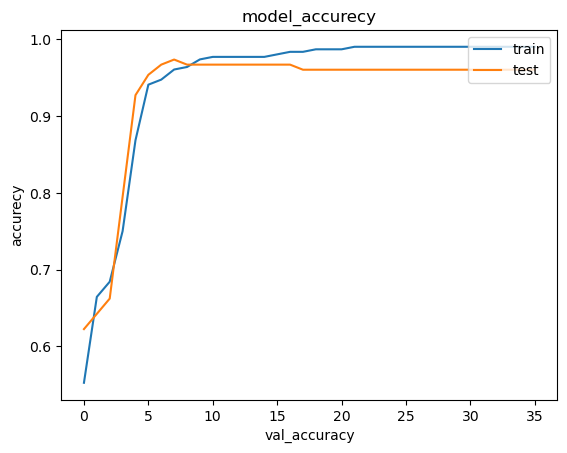

In [21]:
plt.plot(model_history.history["accuracy"])
plt.plot(model_history.history["val_accuracy"])
plt.title("model_accurecy")
plt.ylabel("accurecy")
plt.xlabel("val_accuracy")
plt.legend(["train","test"],loc="upper right")

In [22]:
y_pred = classifier.predict(x_test)
y_pred = (y_pred>=0.5)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [23]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred,y_test))

0.41228070175438597


# with out Scaling

In [24]:
model_history = classifier.fit(x_train,y_train,validation_split=0.33,batch_size = 10,epochs=1000,callbacks=early_stoping)

Epoch 1/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3396 - loss: 509.9085 - val_accuracy: 0.6159 - val_loss: 32.8861
Epoch 2/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6434 - loss: 23.5261 - val_accuracy: 0.8411 - val_loss: 1.3022
Epoch 3/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8541 - loss: 0.8533 - val_accuracy: 0.7483 - val_loss: 1.3319
Epoch 4/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7822 - loss: 1.3996 - val_accuracy: 0.8543 - val_loss: 1.1661
Epoch 5/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8813 - loss: 0.9225 - val_accuracy: 0.8477 - val_loss: 0.7631
Epoch 6/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8506 - loss: 1.1477 - val_accuracy: 0.8808 - val_loss: 0.8651
Epoch 7/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8762 - loss: 0.8313 - val_accuracy: 0.8146 - val_loss: 0.7690
Epoch 8/1000
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8524 - loss: 0.8134 - val_accuracy

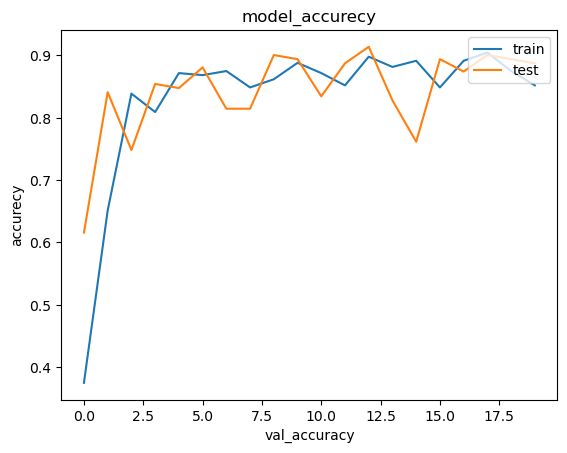

In [25]:
plt.plot(model_history.history["accuracy"])
plt.plot(model_history.history["val_accuracy"])
plt.title("model_accurecy")
plt.ylabel("accurecy")
plt.xlabel("val_accuracy")
plt.legend(["train","test"],loc="upper right")

In [26]:
y_pred = classifier.predict(x_test)
y_pred = (y_pred>=0.5)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [27]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred,y_test))

0.8947368421052632
